In [212]:
import pandas as pd
import matplotlib.pyplot as plt

In [213]:
df = pd.read_csv('OpenAlexData.csv', index_col=0)

C:\Users\wieke\AppData\Local\Temp\ipykernel_13708\2055085896.py:1: DtypeWarning: Columns (8,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('OpenAlexData.csv', index_col=0)


In [214]:
pd.set_option("display.max_columns", 55)


In [215]:
def counts(col1, col2, col3, df):
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col3] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]
    oa_count_s
    return oa_count_s.sort_values(by=[col3], ascending=False)
    



In [216]:
def multiple_counts(col1, col2, col3, col4, df):
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col4] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s['Total'] = oa_count_s[True] + oa_count_s[False]

    
    return oa_count_s


In [217]:
def oa_status(df, col1, col2, sorted):
    oa_status_df = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_status_df = oa_status_df.fillna(0)
    oa_status_df['total'] = oa_status_df['bronze'] + oa_status_df['closed'] + oa_status_df['gold'] + oa_status_df['green'] + oa_status_df['hybrid']
    oa_status_df['hybrid %'] = oa_status_df['hybrid'] / oa_status_df['total']
    oa_status_df['green %'] = oa_status_df['green'] / oa_status_df['total']
    oa_status_df['gold %'] = oa_status_df['gold'] / oa_status_df['total']
    oa_status_df['closed %'] = oa_status_df['closed'] / oa_status_df['total']
    oa_status_df['bronze %'] = oa_status_df['bronze'] / oa_status_df['total']
    dct = {'hybrid %': 'hybrid', 'green %': 'green', 'gold %': 'gold', 'closed %': 'closed', 'bronze %': 'bronze'}
    oa_status_df['Most used OA type'] = oa_status_df[['hybrid %', 'green %', 'gold %', 'closed %', 'bronze %']].idxmax(axis=1).map(dct)

    #oa_status_df = oa_status_df.sort_values(by=[sort], ascending=False)
    oa_status_df = oa_status_df.sort_values(by=[sorted], ascending=False).reset_index(drop=True)

    return oa_status_df

In [218]:
df.head()

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
0,https://openalex.org/W213417050,https://doi.org/10.1037/e675542012-001,dataset,funder,Cognitive Therapy for Depression,2012,2012-01-01,en,https://openalex.org/T11071,Treatment of Major Depression,https://openalex.org/subfields/2736,Pharmacology,https://openalex.org/fields/27,Medicine,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5059319052,Aaron T. Beck,last,https://orcid.org/0000-0001-6210-9528,https://openalex.org/I79576946,University of Pennsylvania,"Psychology,University of Pennsylvania",US,https://ror.org/00b30xv10,https://openalex.org/I79576946
1,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5025339678,John W. Creswell,first,https://orcid.org/0000-0002-5006-880X,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
2,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5021840711,Vicki L. Plano Clark,middle,https://orcid.org/0000-0002-9709-7982,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
3,https://openalex.org/W1639235375,https://doi.org/10.1037/e671332011-001,dataset,funder,The Loss of Sadness: How Psychiatry Transforme...,2009,2009-01-01,en,https://openalex.org/T12308,Mental Health and Psychiatry,https://openalex.org/subfields/1211,Philosophy,https://openalex.org/fields/12,Arts and Humanities,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5091505956,Jerome C. Wakefield,last,https://orcid.org/0000-0002-6809-5515,https://openalex.org/I57206974,New York University,"New York University, New York, NY, US",US,https://ror.org/0190ak572,https://openalex.org/I57206974
4,https://openalex.org/W2995669665,https://doi.org/10.1037/e555342011-003,dataset,funder,Cognitive Therapy for Depression,1996,1996-01-01,en,https://openalex.org/T13272,Psychological Treatments and Assessments,https://openalex.org/subfields/3203,Clinical Psychology,https://openalex.org/fields/32,Psychology,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5047792029,Aaron T. Beck,last,NaN,https://openalex.org/I79576946,University of Pennsylvania,"Department of Psychiatry, School of Medicine, ...",US,https://ror.org/00b30xv10,https://openalex.org/I79576946


In [219]:
df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        435461
Harvard Dataverse                                                                       30117
Zenodo (CERN European Organization for Nuclear Research)                                16798
Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature            16336
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)     13256
Figshare                                                                                 2976
IUPAC Standards Online                                                                    915
Default Digital Object Group                                                              579
PsycEXTRA Dataset                                                                         370
Authorea                                                                                  102
Artifact Digital Object Group                    

In [220]:
Michigan_df = df[df['institution_name'] == 'University of Michigan–Ann Arbor']
#ror_df = unnested_df[(unnested_df['ror'] == 'https://ror.org/0190ak572')]
Michigan_df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        434717
Harvard Dataverse                                                                        9034
Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature             2555
Zenodo (CERN European Organization for Nuclear Research)                                 1422
Figshare                                                                                  554
IUPAC Standards Online                                                                    145
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)        72
Default Digital Object Group                                                               60
PsycEXTRA Dataset                                                                          59
Pancreapedia: The Exocrine Pancreas Knowledge Base                                         51
AEA Randomized Controlled Trials                 

In [221]:
Michigan_df.groupby(['Repository', 'publication_year']).size().sort_values(ascending=False).head(15)


Repository                                                                    publication_year
ENCODE Datasets                                                               2022                434618
Harvard Dataverse                                                             2020                  3823
                                                                              2019                  3565
                                                                              2012                   584
Zenodo (CERN European Organization for Nuclear Research)                      2023                   429
                                                                              2021                   370
Figshare                                                                      2023                   363
Harvard Dataverse                                                             2018                   257
Zenodo (CERN European Organization for Nuclear Research)         

In [222]:
encode_test = df[(df['Repository'] == 'ENCODE Datasets')]
len(encode_test) 

435461

In [223]:
# remove faculty opinions as it is not a dataset content
df = df.replace({'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature': 'Faculty Opinions Ltd'})

OAInstitution_df = df.copy()
OAInstitution_df = OAInstitution_df[OAInstitution_df['Repository'] != 'Faculty Opinions Ltd']
df2022 = OAInstitution_df[OAInstitution_df['publication_year'] >= 2022]
df2021 = OAInstitution_df[OAInstitution_df['publication_year'] <= 2021]

In [224]:
institutions_df = counts('institution_name', 'is_oa', 'OA %', OAInstitution_df).reset_index(drop=True)
institutions_df

is_oa,institution_name,False,True,OA %,Total
0,University of Michigan–Ann Arbor,998,445209,0.997763,446207
1,University of Pennsylvania,69,1881,0.964615,1950
2,Princeton University,219,5568,0.962157,5787
3,New York University,305,4105,0.930839,4410
4,University of Colorado Boulder,95,855,0.900000,950
5,University of Virginia,216,1781,0.891838,1997
6,Virginia Tech,120,891,0.881306,1011
7,Pennsylvania State University,448,3098,0.873660,3546
8,Michael J. Fox Foundation,1,5,0.833333,6
9,University of Illinois Urbana-Champaign,354,1639,0.822378,1993


In [225]:
institutions_2022df = counts('institution_name', 'is_oa', 'OA %', df2022).reset_index(drop=True)
institutions_2022df 

is_oa,institution_name,False,True,OA %,Total
0,University of Michigan–Ann Arbor,711,435365,0.998370,436076
1,University of Virginia,26,448,0.945148,474
2,University of Pennsylvania,26,230,0.898438,256
3,New York University,83,726,0.897404,809
4,Virginia Tech,59,494,0.893309,553
5,University of Colorado Boulder,21,152,0.878613,173
6,Princeton University,141,843,0.856707,984
7,Michael J. Fox Foundation,1,5,0.833333,6
8,University of New Mexico,6,28,0.823529,34
9,Pennsylvania State University,191,796,0.806484,987


In [226]:
institutions_2021df = counts('institution_name', 'is_oa', 'OA %', df2021).reset_index(drop=True)
institutions_2021df 

is_oa,institution_name,False,True,OA %,Total
0,Princeton University,78,4725,0.983760,4803
1,University of Pennsylvania,43,1651,0.974616,1694
2,University of Michigan–Ann Arbor,287,9844,0.971671,10131
3,Cornell University,261,6837,0.963229,7098
4,New York University,222,3379,0.938350,3601
5,University of Colorado Boulder,74,703,0.904762,777
6,Pennsylvania State University,257,2302,0.899570,2559
7,University of Virginia,190,1333,0.875246,1523
8,Virginia Tech,61,397,0.866812,458
9,Washington University in St. Louis,284,1848,0.866792,2132


<Axes: title={'center': 'Comparing OA % Across Institutions from before 2022 and 2022 Beyond'}, ylabel='institution_name'>

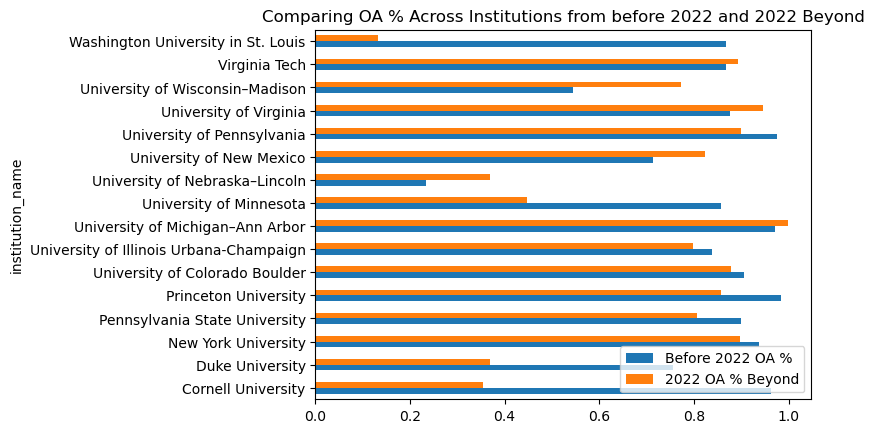

In [227]:
oa_df1 = counts('institution_name', 'is_oa', 'OA %', df2021).sort_values('institution_name', ascending=True)
oa_df2 = counts('institution_name', 'is_oa', 'OA %', df2022).sort_values('institution_name', ascending=True)
oa_df2 = oa_df2[oa_df2['institution_name'] != 'Michael J. Fox Foundation']

oa_df1 = oa_df1.rename(columns={'OA %': 'Before 2022 OA %'})
oa_df2 = oa_df2.rename(columns={'OA %': '2022 OA % Beyond'})

oa_df2 = oa_df2.reset_index(drop=True)
oa_df1 = pd.concat([oa_df1, oa_df2['2022 OA % Beyond']], axis=1)


# plotting sorted  by 2020 Diff 2018 on all there subjects (largest to smallest change)

oa_df_plot = oa_df1.plot(x="institution_name", y=['Before 2022 OA %', '2022 OA % Beyond'], kind="barh") 
oa_df_plot.set_title('Comparing OA % Across Institutions from before 2022 and 2022 Beyond')

oa_df_plot

In [228]:
rads_df = pd.read_csv('RADS_Datasets_MN.csv')
rads_df.head()


,institution,id,type,DOI,publisher,container_type,container_title,container_volume,container_firstPage,container_identifier,container_identifierType,container_lastPage,publicationYear,language,ris,bibtex,citeproc,schemaOrg,resourceType,resourceTypeGeneral,version,URL,metadataVersion,schemaVersion,source,isActive,state,...,downloadCount,referenceCount,citationCount,partCount,partOfCount,versionCount,versionOfCount,created,registered,published,updated,data_id,data_type,container_issue,group,member,reference-count,title,created.date-parts2,created.date-parts3,created.date-time,created.timestamp,name,doi,url,container.title,publisher_plus
0,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25.000Z,2011-08-26T16:27:25.000Z,2015.0,2020-07-28T04:29:43.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Minnesota,10.5061/dryad.gr43t,dois,10.5061/dryad.gr43t,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,10.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,16.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-08-26T16:27:25Z,2011-08-26T16:27:25Z,NaN,2022-06-01T22:50:13Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,4.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,15.0,1.0,0.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08.000Z,2011-11-29T19:14:08.000Z,2016.0,2020-07-28T04:32:35.000Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Minnesota,10.5061/dryad.rb3b0d2p,dois,10.5061/dryad.rb3b0d2p,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,en,DATA,misc,dataset,Dataset,dataset,Dataset,2,http://datadryad.org/stash/dataset/doi:10.5061...,6.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,31.0,1.0,1.0,0.0,0.0,0.0,0.0,2011-11-29T19:14:08Z,2011-11-29T19:14:08Z,NaN,2022-06-01T22:29:52Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Minnesota,10.5061/dryad.rk5fp6n9,dois,10.5061/dryad.rk5fp6n9,Dryad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012,en,DATA,misc,dataset,Dataset,dataset,Dataset,1,http://datadryad.org/stash/dataset/doi:10.5061...,16.0,http://datacite.org/schema/kernel-4,mds,True,findable,...,9.0,1.0,1.0,1.0,0.0,0.0,0.0,2012-01-05T21:18:31Z,2012-01-05T21:18:31Z,NaN,2022-05-31T22:46:15Z,dryad.dryad,clients,NaN,Affiliation - Datacite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [229]:
len(rads_df)

4971

In [230]:
rads_df = rads_df[['institution', 'id', 'DOI', 'group', 'publisher', 'publicationYear', 'resourceTypeGeneral', 'resourceType', 'schemaOrg', 'citeproc', 'source', 'state']]

rads_df = rads_df.rename(columns={'resourceType': 'subjectType', 'publisher': 'Repository', 'group': 'index location'})
rads_df = rads_df.rename(columns={'publisher': 'Repository'})	
#rads_df = rads_df.replace({'Harvard Dataverse': 'Harvard dataverse'})
rads_df = rads_df.replace({'Zenodo': 'Zenodo (CERN European Organization for Nuclear Research)', 'figshare': 'Figshare', 'Affiliation - Datacite': 'datacite', 'Affiliation - CrossRef': 'crossref'})


rads_df = rads_df.replace('dataset', 'Dataset')
rads_df.head()

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [231]:
rads_df['index location'].value_counts()

index location
datacite        2580
crossref        1700
IR_publisher     691
Name: count, dtype: int64

In [232]:
rads_df['resourceTypeGeneral'].value_counts()

resourceTypeGeneral
Dataset    4971
Name: count, dtype: int64

In [233]:
rads_df['subjectType'].value_counts().head(20)

subjectType
Dataset                                         876
Dataset/Paleoecological Sample Data             210
Experimental Data                                79
Field Study Data                                 45
survey data                                      37
Simulation Data                                  31
Genomics Data                                    29
Programming Software Code                        24
Other Dataset                                    22
Specialized Mix                                  20
Experimental Data||Field Study Data              19
Field Study Data||Observational Data             19
Spatial Data                                     17
3D Imaging Data                                  16
Observational Data                               14
Programming Software Code||Simulation Data       12
Mass Spectrometry                                11
Experimental Data||Programming Software Code     10
Survey Data-Quantitative                          9


In [234]:
rads_df['citeproc'].value_counts().head(15)

citeproc
Dataset    2578
article       2
Name: count, dtype: int64

In [235]:
def RadsCounts(col1, col2, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [236]:
def RadsMultipleCounts(col1, col2, col3, df, sort):
    #oa_count_s = df.groupby([[col1, col2]])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    #oa_count_s['total'] = df.groupby['publisher']['DOI'].size()
    
    
    #oa_count_s = oa_count_s.fillna(0)
    
    return oa_count_s.sort_values(by=[sort], ascending=False).reset_index(drop=True)

In [237]:
rads_df.head(15)

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
5,Minnesota,10.5061/dryad.3b2q4g1m,10.5061/dryad.3b2q4g1m,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
6,Minnesota,10.4232/1.11090,10.4232/1.11090,datacite,GESIS Data Archive,2012,Dataset,NaN,Dataset,Dataset,mds,findable
7,Minnesota,10.5061/dryad.d2c619hd,10.5061/dryad.d2c619hd,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
8,Minnesota,10.5061/dryad.nf91079h,10.5061/dryad.nf91079h,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable
9,Minnesota,10.5061/dryad.5k3t47p0,10.5061/dryad.5k3t47p0,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [238]:
OAFac_df = df.copy()
Rads_Fac_df = rads_df.copy()
#OAInstitution_df = OAInstitution_df[OAInstitution_df['Repository'] != 'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature']
Fac2022df = OAFac_df[OAFac_df['publication_year'] >= 2022]
Fac2021df = OAFac_df[OAFac_df['publication_year'] <= 2021]

Fac2022df = Fac2022df[Fac2022df['institution_name'] == 'University of Minnesota']
Fac2021df = Fac2021df[Fac2021df['institution_name'] == 'University of Minnesota']

In [239]:

MNFac_2021_repo_df = counts('Repository', 'is_oa', 'OA %', Fac2021df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
#MNFac_2021_repo_df = MNFac_2021_repo_df.replace({'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature': 'Faculty Opinions Ltd'})
MNFac_2021_repo_df

is_oa,Repository,False,True,OA %,Total
0,Faculty Opinions Ltd,1039.0,379.0,0.267278,1418.0
1,Default Digital Object Group,47.0,9.0,0.160714,56.0
2,OSTI OAI (U.S. Department of Energy Office of ...,26.0,0.0,0.000000,26.0
3,IUPAC Standards Online,6.0,26.0,0.812500,32.0
4,PMC,5.0,0.0,0.000000,5.0
5,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
6,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
7,Figshare,0.0,12.0,1.000000,12.0
8,Harvard Dataverse,0.0,362.0,1.000000,362.0
9,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,5.0,1.000000,5.0


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Pre 2022 Repository Counts')

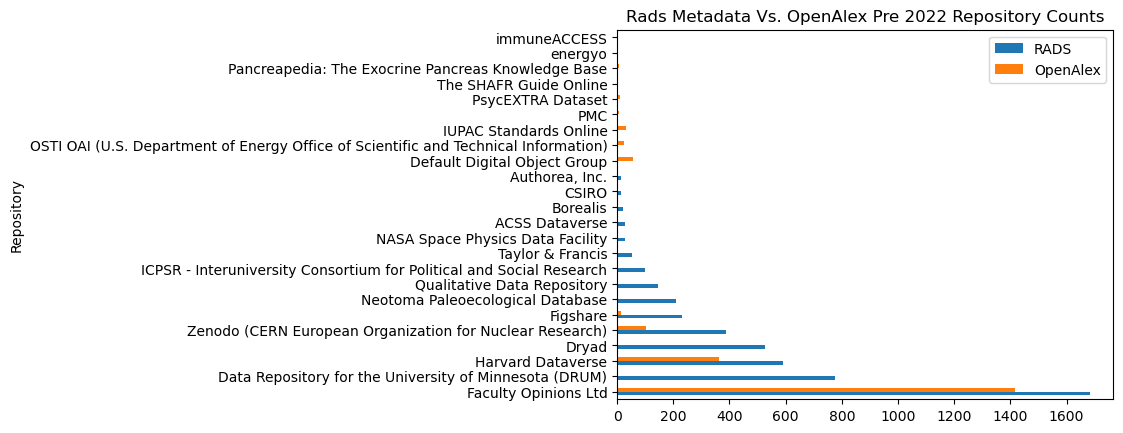

In [240]:
RadsFacDF = RadsCounts('Repository', 'resourceTypeGeneral', Rads_Fac_df, 'Dataset')

#merged.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh", stacked=True).set_title('Rads Metadata Vs. OpenAlex Pre 2022 Metadata')
OARadsFacDf = pd.merge(RadsFacDF.head(15), MNFac_2021_repo_df, on='Repository', how='outer')
OARadsFacDf = OARadsFacDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

OARadsFacDf.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Pre 2022 Repository Counts')

In [242]:
# remove faculty opinions as it is not a dataset content
df= df[df['Repository'] != 'Faculty Opinions Ltd']

rads_df = rads_df[rads_df['Repository'] != 'Faculty Opinions Ltd']

# remove encode if wanting to remove this scope
#encode_removed_df = df[(df['Repository'] != 'ENCODE Datasets')]

# subset a new df to only UMN
MN_df = df[df['institution_name'] == 'University of Minnesota']

# subset two new dfs by year
MN_2022df = MN_df[MN_df['publication_year'] >= 2022]
MN_2021df = MN_df[MN_df['publication_year'] <= 2021]

In [243]:
MN_2021_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2021df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_2021_repo_df 

is_oa,Repository,False,True,OA %,Total
0,Default Digital Object Group,47.0,9.0,0.160714,56.0
1,OSTI OAI (U.S. Department of Energy Office of ...,26.0,0.0,0.000000,26.0
2,IUPAC Standards Online,6.0,26.0,0.812500,32.0
3,PMC,5.0,0.0,0.000000,5.0
4,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
5,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
6,Figshare,0.0,12.0,1.000000,12.0
7,Harvard Dataverse,0.0,362.0,1.000000,362.0
8,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,5.0,1.000000,5.0
9,Zenodo (CERN European Organization for Nuclear...,0.0,102.0,1.000000,102.0


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Pre 2022 Repository Counts')

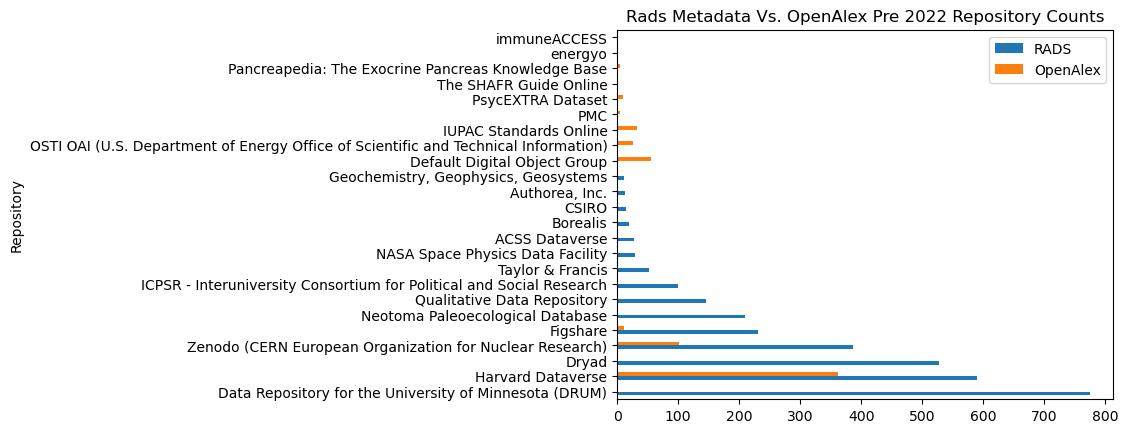

In [244]:
RadsRepoDF = RadsCounts('Repository', 'resourceTypeGeneral', rads_df, 'Dataset')

RadsRepoDF.head(25)
#merged.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh", stacked=True).set_title('Rads Metadata Vs. OpenAlex Pre 2022 Metadata')
OARadsRepoDf = pd.merge(RadsRepoDF.head(15), MN_2021_repo_df, on='Repository', how='outer')
OARadsRepoDf = OARadsRepoDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})

OARadsRepoDf.plot(x="Repository", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Pre 2022 Repository Counts')

In [245]:
len(Fac2021df), len(Rads_Fac_df), len(MN_2021df), len(rads_df)

(2032, 4971, 614, 3289)

In [246]:
FacData = {'Repository': ['RADS', 'OpenAlex'], 'Includes Faculty Opinions': pd.Series([len(Fac2021df), len(Rads_Fac_df)]), 'No Faculty Opinions': pd.Series([len(MN_2021df), len(rads_df)])}
FacOpinionsCounts_df = pd.DataFrame(data=FacData, index=[0, 1])
FacOpinionsCounts_df

,Repository,Includes Faculty Opinions,No Faculty Opinions
0,RADS,2032,614
1,OpenAlex,4971,3289


Text(0.5, 1.0, 'Rads and OpenAlex Faculty Comparison')

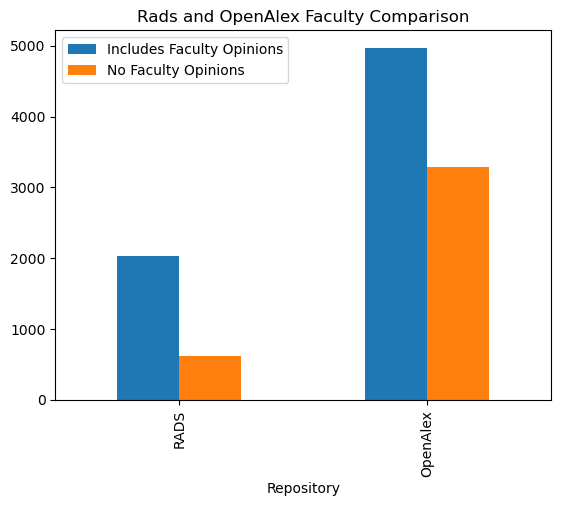

In [247]:
FacOpinionsCounts_df.plot(x="Repository", y=["Includes Faculty Opinions", "No Faculty Opinions"], kind="bar").set_title('Rads and OpenAlex Faculty Comparison')

In [248]:
# No FAculty Opinions subject type in RADS data
FacOpinionsSubjects_df = multiple_counts('Repository', 'domain_name', 'is_oa', 'OA %', Fac2021df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
FacOpinionsSubjects_df.head(20)

is_oa,Repository,domain_name,False,True,OA %,Total
0,Faculty Opinions Ltd,Life Sciences,535.0,230.0,0.300654,765.0
1,Faculty Opinions Ltd,Health Sciences,359.0,112.0,0.237792,471.0
2,Faculty Opinions Ltd,Physical Sciences,95.0,27.0,0.221311,122.0
3,Faculty Opinions Ltd,Social Sciences,50.0,10.0,0.166667,60.0
4,OSTI OAI (U.S. Department of Energy Office of ...,Physical Sciences,21.0,0.0,0.000000,21.0
5,Default Digital Object Group,Physical Sciences,18.0,0.0,0.000000,18.0
6,PMC,Life Sciences,5.0,0.0,0.000000,5.0
7,OSTI OAI (U.S. Department of Energy Office of ...,Life Sciences,5.0,0.0,0.000000,5.0
8,The SHAFR Guide Online,Social Sciences,2.0,0.0,0.000000,2.0
9,PsycEXTRA Dataset,Life Sciences,1.0,0.0,0.000000,1.0


In [249]:
# No FAculty Opinions subject type in RADS data
FacOpinionsSubjects_df = multiple_counts('Repository', 'field_name', 'is_oa', 'OA %', Fac2021df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
FacOpinionsSubjects_df.head(20)

is_oa,Repository,field_name,False,True,OA %,Total
0,Faculty Opinions Ltd,"Biochemistry, Genetics and Molecular Biology",373.0,171.0,0.314338,544.0
1,Faculty Opinions Ltd,Medicine,321.0,106.0,0.248244,427.0
2,Faculty Opinions Ltd,Agricultural and Biological Sciences,81.0,25.0,0.235849,106.0
3,Faculty Opinions Ltd,Immunology and Microbiology,55.0,25.0,0.312500,80.0
4,Faculty Opinions Ltd,Health Professions,25.0,4.0,0.137931,29.0
5,Faculty Opinions Ltd,Environmental Science,25.0,9.0,0.264706,34.0
6,Faculty Opinions Ltd,Engineering,24.0,9.0,0.272727,33.0
7,Faculty Opinions Ltd,Chemistry,24.0,3.0,0.111111,27.0
8,Faculty Opinions Ltd,Psychology,22.0,5.0,0.185185,27.0
9,OSTI OAI (U.S. Department of Energy Office of ...,Environmental Science,21.0,0.0,0.000000,21.0


In [250]:
Rads_Fac_df.head()

,institution,id,DOI,index location,Repository,publicationYear,resourceTypeGeneral,subjectType,schemaOrg,citeproc,source,state
0,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
1,Minnesota,10.5061/dryad.gr43t,10.5061/dryad.gr43t,datacite,Dryad,2015,Dataset,Dataset,Dataset,Dataset,mds,findable
2,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
3,Minnesota,10.5061/dryad.rb3b0d2p,10.5061/dryad.rb3b0d2p,datacite,Dryad,2016,Dataset,Dataset,Dataset,Dataset,mds,findable
4,Minnesota,10.5061/dryad.rk5fp6n9,10.5061/dryad.rk5fp6n9,datacite,Dryad,2012,Dataset,Dataset,Dataset,Dataset,mds,findable


In [251]:
#source = RadsCounts('Repository', 'source', rads_df, 'source')
Rads_Fac_df.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)

,Repository,index location,count
0,Faculty Opinions Ltd,crossref,1682
1,Data Repository for the University of Minnesot...,IR_publisher,691
2,Harvard Dataverse,datacite,590
3,Dryad,datacite,528
4,Zenodo (CERN European Organization for Nuclear...,datacite,387
5,Figshare,datacite,231
6,Neotoma Paleoecological Database,datacite,210
7,Qualitative Data Repository,datacite,145
8,ICPSR - Interuniversity Consortium for Politic...,datacite,99
9,Data Repository for the University of Minnesot...,datacite,83


In [252]:
FacOnlyOA = Fac2021df[Fac2021df['Repository'] == 'Faculty Opinions Ltd']
FacOnlyRads =  Rads_Fac_df[Rads_Fac_df['Repository'] == 'Faculty Opinions Ltd']

In [253]:
FacOnlyOAIndex = multiple_counts('Repository', 'index location', 'is_oa', 'OA %', FacOnlyOA).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)

#FacOnlyOAIndex = FacOnlyOA.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
FacOnlyOAIndex = FacOnlyOAIndex.rename(columns={"count": "OpenAlex"})

FacOnlyOAIndex


is_oa,Repository,index location,False,True,OA %,Total
0,Faculty Opinions Ltd,crossref,1039,379,0.267278,1418


In [254]:
FacOnlyRadsIndex =FacOnlyRads.groupby(['Repository'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
FacOnlyRadsIndex = FacOnlyRadsIndex.rename(columns={"count": "RADS"})

FacOnlyRadsIndex

,Repository,index location,RADS
0,Faculty Opinions Ltd,crossref,1682


Text(0.5, 1.0, 'OpenAlex Vs. RADS Faculty Opinion Index Location Counts')

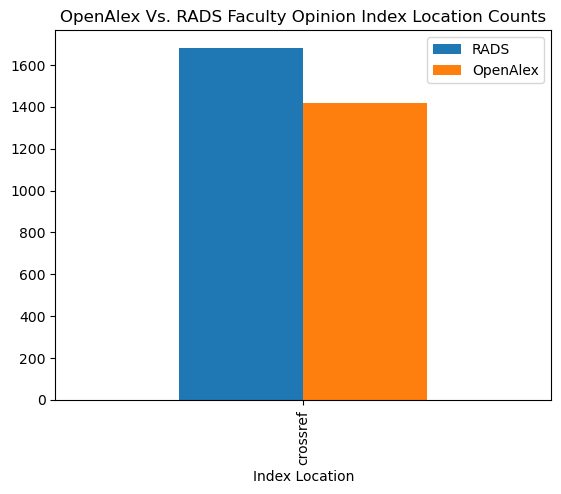

In [255]:
OARadsIndexDf = pd.merge(FacOnlyOAIndex, FacOnlyRadsIndex, on='Repository', how='inner')
OARadsIndexDf = OARadsIndexDf.rename(columns={"count_x": "RADS",  "Total": "OpenAlex", "index location_x": "Index Location"})

OARadsIndexDf.plot(x="Index Location", y=["RADS", "OpenAlex"], kind="bar").set_title('OpenAlex Vs. RADS Faculty Opinion Index Location Counts')

In [256]:
OA_FacYear_df = multiple_counts('Repository', 'publication_year', 'is_oa', 'OA %', FacOnlyOA).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
OA_FacYear_df = OA_FacYear_df.sort_values(by='Total', ascending=False).reset_index(drop=True)
OA_FacYear_df = OA_FacYear_df[['Repository', 'publication_year', 'Total']].sort_values(by='publication_year', ascending=False).reset_index(drop=True)
OA_FacYear_df

is_oa,Repository,publication_year,Total
0,Faculty Opinions Ltd,2021,51
1,Faculty Opinions Ltd,2020,123
2,Faculty Opinions Ltd,2019,83
3,Faculty Opinions Ltd,2018,50
4,Faculty Opinions Ltd,2017,110
5,Faculty Opinions Ltd,2016,105
6,Faculty Opinions Ltd,2015,40
7,Faculty Opinions Ltd,2014,93
8,Faculty Opinions Ltd,2013,103
9,Faculty Opinions Ltd,2012,88


In [257]:
Rads_FacYear_df = FacOnlyRads.groupby(['Repository'])['publicationYear'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
Rads_FacYear_df = Rads_FacYear_df.rename(columns={"count": "RADS",  "Total": "OpenAlex", "publicationYear":"publication_year"})
Rads_FacYear_df = Rads_FacYear_df.sort_values(by='publication_year', ascending=False).reset_index(drop=True)


Rads_FacYear_df

,Repository,publication_year,RADS
0,Faculty Opinions Ltd,2022,15
1,Faculty Opinions Ltd,2021,69
2,Faculty Opinions Ltd,2020,264
3,Faculty Opinions Ltd,2019,122
4,Faculty Opinions Ltd,2018,63
5,Faculty Opinions Ltd,2017,111
6,Faculty Opinions Ltd,2016,120
7,Faculty Opinions Ltd,2015,46
8,Faculty Opinions Ltd,2014,93
9,Faculty Opinions Ltd,2013,98


In [258]:
FacYear_df = pd.merge(OA_FacYear_df, Rads_FacYear_df, on='publication_year', how='outer')
FacYear_df = FacYear_df.rename(columns={"Repository_x": "Repository",  "Total": "OpenAlex"})

FacYear_df = FacYear_df[['Repository', 'publication_year', 'RADS', 'OpenAlex']]

FacYear_df['Repository'] = FacYear_df['Repository'].fillna('Faculty Opinions Ltd')

FacYear_df = FacYear_df.sort_values(by=['publication_year'], ascending=False)
FacYear_df

,Repository,publication_year,RADS,OpenAlex
21,Faculty Opinions Ltd,2022,15.0,NaN
0,Faculty Opinions Ltd,2021,69.0,51.0
1,Faculty Opinions Ltd,2020,264.0,123.0
2,Faculty Opinions Ltd,2019,122.0,83.0
3,Faculty Opinions Ltd,2018,63.0,50.0
4,Faculty Opinions Ltd,2017,111.0,110.0
5,Faculty Opinions Ltd,2016,120.0,105.0
6,Faculty Opinions Ltd,2015,46.0,40.0
7,Faculty Opinions Ltd,2014,93.0,93.0
8,Faculty Opinions Ltd,2013,98.0,103.0


Text(0.5, 1.0, 'Faculty Opinions Publication Year Counts')

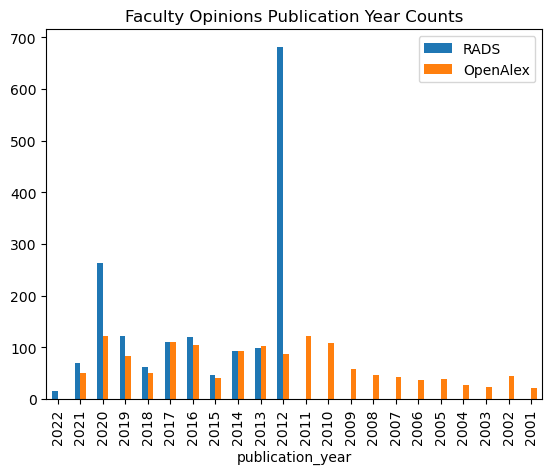

In [259]:
FacYear_df.plot(x="publication_year", y=["RADS", "OpenAlex"], kind="bar").set_title('Faculty Opinions Publication Year Counts')


# Removing Faculty Opinions

In [260]:
RadsYear_df = RadsCounts('publicationYear', 'resourceTypeGeneral', rads_df, 'publicationYear')
RadsYear_df = RadsYear_df.rename(columns={"Dataset": "RADS",  "publicationYear": "publication_year"})

RadsYear_df

#mn_year_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
#mn_year_df = mn_year_df.rename(columns={"Total": "OpenAlex"})

resourceTypeGeneral,publication_year,RADS
0,2022,655
1,2021,448
2,2020,525
3,2019,383
4,2018,385
5,2017,579
6,2016,113
7,2015,78
8,2014,39
9,2013,51


In [261]:

OAYear_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
OAYear_df = OAYear_df.rename(columns={"Total": "OpenAlex"})
OAYear_df

is_oa,institution_name,publication_year,False,True,OA %,OpenAlex
19,University of Minnesota,2024,16.0,5.0,0.238095,21.0
18,University of Minnesota,2023,14.0,57.0,0.802817,71.0
17,University of Minnesota,2022,229.0,148.0,0.392573,377.0
16,University of Minnesota,2021,0.0,53.0,1.000000,53.0
15,University of Minnesota,2020,10.0,144.0,0.935065,154.0
14,University of Minnesota,2019,8.0,104.0,0.928571,112.0
13,University of Minnesota,2018,5.0,105.0,0.954545,110.0
12,University of Minnesota,2017,6.0,8.0,0.571429,14.0
11,University of Minnesota,2016,10.0,29.0,0.743590,39.0
10,University of Minnesota,2015,0.0,4.0,1.000000,4.0


Text(0.5, 1.0, 'Rads Vs. OpenAlex Total Publication Counts by Year')

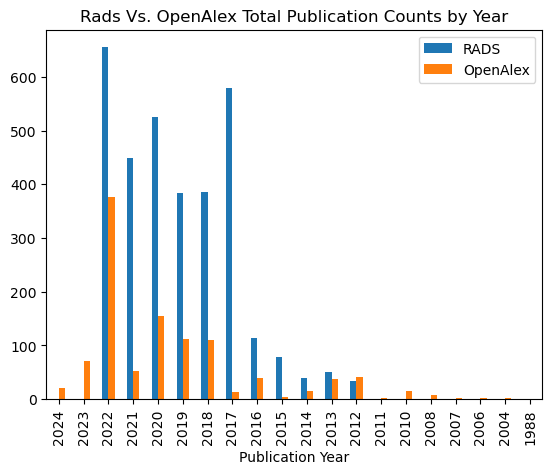

In [262]:

OARadsYearsDf = pd.merge(OAYear_df, RadsYear_df, on='publication_year', how='outer')
OARadsYearsDf = OARadsYearsDf.rename(columns={"publication_year": "Publication Year"})
OARadsYearsDf.plot(x="Publication Year", y=["RADS", "OpenAlex"], kind="bar").set_title('Rads Vs. OpenAlex Total Publication Counts by Year')

In [ ]:
RadsAllIndexDf = rads_df.groupby(['index location'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
RadsAllIndexDf = RadsAllIndexDf.rename(columns={"count": "RADS"})
RadsAllIndexDf = RadsAllIndexDf[['index location', 'RADS']]
RadsAllIndexDf

,index location,RADS
0,datacite,2580
1,IR_publisher,691
2,crossref,18


In [287]:
OAAllIndexDf = MN_df.groupby(['index location'])['index location'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
OAAllIndexDf = OAAllIndexDf.rename(columns={"count": "OpenAlex"})
OAAllIndexDf = OAAllIndexDf[['index location', 'OpenAlex']]
OAAllIndexDf

,index location,OpenAlex
0,datacite,709
1,crossref,329


Text(0.5, 1.0, 'Rads Metadata Vs. OpenAlex Index Location Counts')

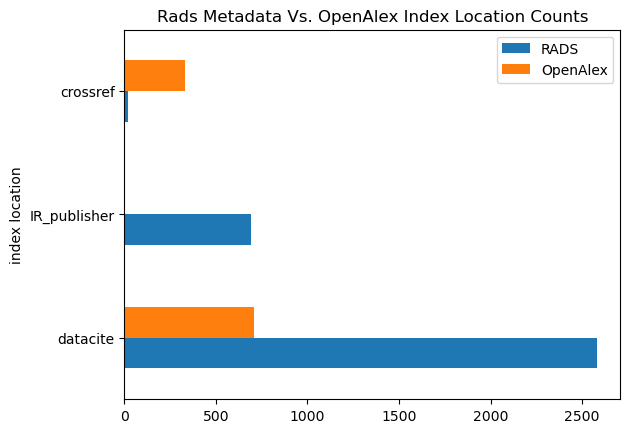

In [288]:
OARadsIndexDf = pd.merge(RadsAllIndexDf, OAAllIndexDf, on='index location', how='outer')
OARadsIndexDf = OARadsIndexDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})
OARadsIndexDf 

OARadsIndexDf.plot(x="index location", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Index Location Counts')


In [419]:
rads_subject_df = rads_df[rads_df['subjectType'] != 'Dataset']


In [426]:
RadsAllSubjectDf = rads_subject_df.groupby(['subjectType'])['subjectType'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
RadsAllSubjectDf = RadsAllSubjectDf.rename(columns={"count": "RADS"})
RadsAllSubjectDf = RadsAllSubjectDf[['subjectType', 'RADS']]
RadsAllSubjectDf

,subjectType,RADS
0,Dataset/Paleoecological Sample Data,210
1,Experimental Data,79
2,Field Study Data,45
3,survey data,37
4,Simulation Data,31
5,Genomics Data,29
6,Programming Software Code,24
7,Other Dataset,22
8,Specialized Mix,20
9,Field Study Data||Observational Data,19


In [432]:
OAAllSubFieldDf = MN_df.groupby(['subfield_name'])['subfield_name'].value_counts().reset_index().sort_values(by='count', ascending=False).head(20).reset_index(drop=True)
OAAllSubFieldDf = OAAllSubFieldDf.rename(columns={"count": "OpenAlex", "subfield_name": 'subjectType'})
OAAllSubFieldDf = OAAllSubFieldDf[['subjectType', 'OpenAlex']]
OAAllSubFieldDf

,subjectType,OpenAlex
0,Computational Theory and Mathematics,111
1,Astronomy and Astrophysics,59
2,Sociology and Political Science,41
3,Molecular Biology,40
4,Political Science and International Relations,33
5,Spectroscopy,30
6,Pharmacology,29
7,Atmospheric Science,20
8,"Radiology, Nuclear Medicine and Imaging",19
9,Plant Science,19


In [ ]:
OARadsSubjectDf = pd.merge(RadsAllSubjectDf, OAAllSubFieldDf, on='subjectType', how='outer')
OARadsSubjectDf = OARadsSubjectDf.rename(columns={"Dataset": "RADS",  "Total": "OpenAlex"})
OARadsSubjectDf 

#OARadsSubjectDf.plot(x="subjectType", y=["RADS", "OpenAlex"], kind="barh").set_title('Rads Metadata Vs. OpenAlex Index Location Counts')


,subjectType,RADS,OpenAlex
0,Dataset/Paleoecological Sample Data,210.0,NaN
1,Experimental Data,79.0,NaN
2,Field Study Data,45.0,NaN
3,survey data,37.0,NaN
4,Simulation Data,31.0,NaN
5,Genomics Data,29.0,NaN
6,Programming Software Code,24.0,NaN
7,Other Dataset,22.0,NaN
8,Specialized Mix,20.0,NaN
9,Field Study Data||Observational Data,19.0,NaN


In [264]:
MN_repo_df = counts('Repository', 'is_oa', 'OA %', MN_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_repo_df = MN_repo_df[['Repository', False, True]]
MN_repo_df = MN_repo_df.rename(columns={False: 'Not OA', True: 'Is OA'})

MN_repo_df

is_oa,Repository,Not OA,Is OA
0,IUPAC Standards Online,220.0,26.0
1,Default Digital Object Group,51.0,9.0
2,OSTI OAI (U.S. Department of Energy Office of ...,40.0,0.0
3,Zenodo (CERN European Organization for Nuclear...,23.0,222.0
4,PMC,5.0,0.0
5,Artifact Digital Object Group,4.0,0.0
6,PsycEXTRA Dataset,2.0,8.0
7,The SHAFR Guide Online,2.0,0.0
8,Figshare,0.0,12.0
9,Harvard Dataverse,0.0,452.0


Text(0.5, 1.0, 'OpenAlex Open Access by Repository')

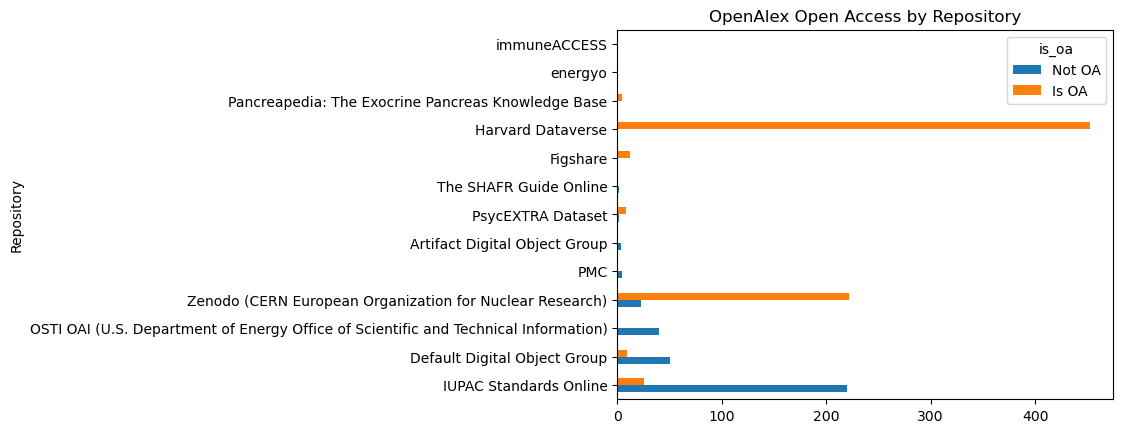

In [265]:
MN_repo_df.plot(x="Repository", y=['Not OA', 'Is OA'], kind="barh").set_title('OpenAlex Open Access by Repository')

In [266]:
MN_2021_repo_df

is_oa,Repository,False,True,OA %,Total
0,Default Digital Object Group,47.0,9.0,0.160714,56.0
1,OSTI OAI (U.S. Department of Energy Office of ...,26.0,0.0,0.000000,26.0
2,IUPAC Standards Online,6.0,26.0,0.812500,32.0
3,PMC,5.0,0.0,0.000000,5.0
4,PsycEXTRA Dataset,2.0,8.0,0.800000,10.0
5,The SHAFR Guide Online,2.0,0.0,0.000000,2.0
6,Figshare,0.0,12.0,1.000000,12.0
7,Harvard Dataverse,0.0,362.0,1.000000,362.0
8,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,5.0,1.000000,5.0
9,Zenodo (CERN European Organization for Nuclear...,0.0,102.0,1.000000,102.0


In [267]:
MN_2022_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2022df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_2022_repo_df 

is_oa,Repository,False,True,OA %,Total
0,IUPAC Standards Online,214.0,0.0,0.000000,214.0
1,Zenodo (CERN European Organization for Nuclear...,23.0,120.0,0.839161,143.0
2,OSTI OAI (U.S. Department of Energy Office of ...,14.0,0.0,0.000000,14.0
3,Artifact Digital Object Group,4.0,0.0,0.000000,4.0
4,Default Digital Object Group,4.0,0.0,0.000000,4.0
5,Harvard Dataverse,0.0,90.0,1.000000,90.0


In [293]:
MN_field_df = counts('field_name', 'is_oa', 'OA %', MN_df).reset_index(drop=True).sort_values(by=False, ascending=False).reset_index(drop=True)
MN_field_df = MN_field_df[['field_name', False, True]]
MN_field_df = MN_field_df.rename(columns={False: 'Not OA', True: 'Is OA', 'field_name': 'Field Name'})

MN_field_df

is_oa,Field Name,Not OA,Is OA
0,Computer Science,114.0,32.0
1,"Biochemistry, Genetics and Molecular Biology",45.0,22.0
2,Environmental Science,36.0,31.0
3,"Pharmacology, Toxicology and Pharmaceutics",34.0,0.0
4,Medicine,24.0,30.0
5,Engineering,20.0,54.0
6,Chemistry,12.0,34.0
7,Agricultural and Biological Sciences,9.0,24.0
8,Physics and Astronomy,6.0,77.0
9,Earth and Planetary Sciences,4.0,37.0


Text(0.5, 1.0, 'OpenAlex Open Access by Field')

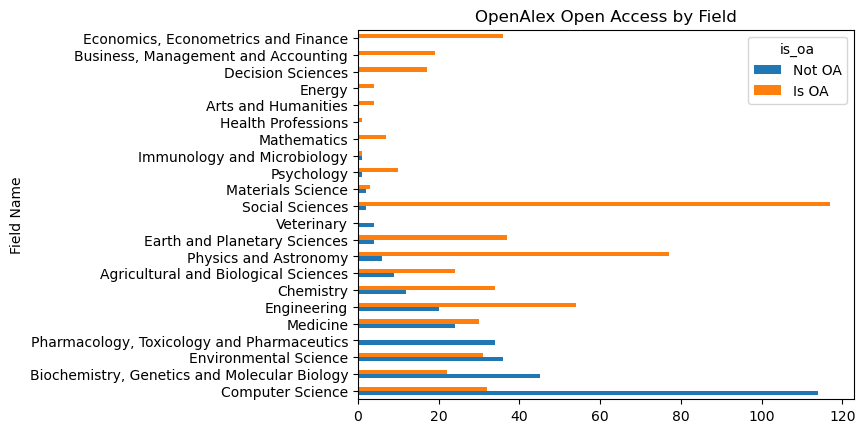

In [269]:
MN_field_df.plot(x="Field Name", y=['Not OA', 'Is OA'], kind="barh").set_title('OpenAlex Open Access by Field')

In [270]:
MN_field2021_df = multiple_counts('field_name', 'Repository', 'is_oa', 'OA %', MN_2021df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(10)
MN_field2021_df

is_oa,field_name,Repository,False,True,OA %,Total
0,Environmental Science,OSTI OAI (U.S. Department of Energy Office of ...,21.0,0.0,0.0,21.0
1,Engineering,Default Digital Object Group,15.0,0.0,0.0,15.0
2,Agricultural and Biological Sciences,PMC,5.0,0.0,0.0,5.0
3,"Biochemistry, Genetics and Molecular Biology",OSTI OAI (U.S. Department of Energy Office of ...,5.0,0.0,0.0,5.0
4,Social Sciences,The SHAFR Guide Online,2.0,0.0,0.0,2.0
5,Materials Science,Default Digital Object Group,2.0,0.0,0.0,2.0
6,"Biochemistry, Genetics and Molecular Biology",PsycEXTRA Dataset,1.0,0.0,0.0,1.0
7,Chemistry,IUPAC Standards Online,1.0,1.0,0.5,2.0
8,Physics and Astronomy,Default Digital Object Group,1.0,0.0,0.0,1.0
9,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,1.0,1.0,0.5,2.0


In [271]:
MN_field2022_df = multiple_counts('field_name', 'Repository', 'is_oa', 'OA %', MN_2022df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(20)
MN_field2022_df['Total'] = MN_field2022_df[True] + MN_field2022_df[False]

MN_field2022_df

is_oa,field_name,Repository,False,True,OA %,Total
0,Computer Science,IUPAC Standards Online,109.0,0.0,0.000000,109.0
1,"Pharmacology, Toxicology and Pharmaceutics",IUPAC Standards Online,34.0,0.0,0.000000,34.0
2,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,33.0,0.0,0.000000,33.0
3,Medicine,IUPAC Standards Online,20.0,0.0,0.000000,20.0
4,Chemistry,IUPAC Standards Online,11.0,0.0,0.000000,11.0
5,Environmental Science,OSTI OAI (U.S. Department of Energy Office of ...,6.0,0.0,0.000000,6.0
6,Environmental Science,IUPAC Standards Online,5.0,0.0,0.000000,5.0
7,"Biochemistry, Genetics and Molecular Biology",Zenodo (CERN European Organization for Nuclear...,4.0,0.0,0.000000,4.0
8,Environmental Science,Zenodo (CERN European Organization for Nuclear...,4.0,4.0,0.500000,8.0
9,Engineering,Default Digital Object Group,4.0,0.0,0.000000,4.0


Text(0.5, 1.0, 'OpenAlex Open Access by Field 2022')

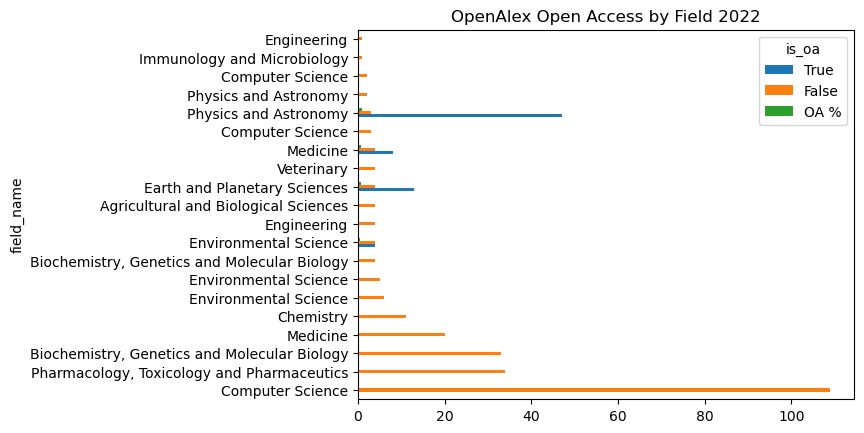

In [272]:
MN_field2022_df.plot(x="field_name", y=[True, False,'OA %'], kind="barh").set_title('OpenAlex Open Access by Field 2022')

In [273]:
MN_subfield2022_df = multiple_counts('subfield_name', 'Repository', 'is_oa', 'OA %', MN_2022df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(25)
MN_subfield2022_df['Total'] = MN_subfield2022_df[True] + MN_subfield2022_df[False]

MN_subfield2022_df

is_oa,subfield_name,Repository,False,True,OA %,Total
0,Computational Theory and Mathematics,IUPAC Standards Online,109.0,0.0,0.000000,109.0
1,Pharmacology,IUPAC Standards Online,29.0,0.0,0.000000,29.0
2,Molecular Biology,IUPAC Standards Online,17.0,0.0,0.000000,17.0
3,Physiology,IUPAC Standards Online,11.0,0.0,0.000000,11.0
4,Physical and Theoretical Chemistry,IUPAC Standards Online,7.0,0.0,0.000000,7.0
5,Global and Planetary Change,OSTI OAI (U.S. Department of Energy Office of ...,6.0,0.0,0.000000,6.0
6,Pharmaceutical Science,IUPAC Standards Online,5.0,0.0,0.000000,5.0
7,Biochemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0
8,Clinical Biochemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0
9,Environmental Chemistry,IUPAC Standards Online,5.0,0.0,0.000000,5.0


In [274]:
MN_subfield2021_df = multiple_counts('subfield_name', 'Repository', 'is_oa', 'OA %', MN_2021df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(16)
MN_subfield2021_df

is_oa,subfield_name,Repository,False,True,OA %,Total
0,Environmental Engineering,OSTI OAI (U.S. Department of Energy Office of ...,11.0,0.0,0.00,11.0
1,Computational Mechanics,Default Digital Object Group,8.0,0.0,0.00,8.0
2,Water Science and Technology,OSTI OAI (U.S. Department of Energy Office of ...,7.0,0.0,0.00,7.0
3,Genetics,OSTI OAI (U.S. Department of Energy Office of ...,5.0,0.0,0.00,5.0
4,Food Science,PMC,5.0,0.0,0.00,5.0
5,Biomedical Engineering,Default Digital Object Group,5.0,0.0,0.00,5.0
6,Pollution,OSTI OAI (U.S. Department of Energy Office of ...,3.0,0.0,0.00,3.0
7,Materials Chemistry,Default Digital Object Group,2.0,0.0,0.00,2.0
8,Civil and Structural Engineering,Default Digital Object Group,2.0,0.0,0.00,2.0
9,Clinical Psychology,PsycEXTRA Dataset,1.0,3.0,0.75,4.0


In [311]:
MN_departments_df = multiple_counts('raw_affiliation_strings', 'Repository', 'is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(33)
MN_departments_df.to_csv('raw_strings.csv')
MN_departments_df = MN_departments_df[['raw_affiliation_strings', False, True]]
MN_departments_df = MN_departments_df.rename(columns={False: 'Not OA', True: 'Is OA', 'raw_affiliation_strings': 'Department'}).head(25)
MN_departments_df['Department'] = MN_departments_df['Department'].str[0:50]
MN_departments_df

is_oa,Department,Not OA,Is OA
0,"Department of Medicinal Chemistry, University ...",214.0,0.0
1,Department of Aerospace Engineering and Mechan...,28.0,0.0
2,University of Minnesota - St. Paul,21.0,0.0
3,"University of Minnesota, Saint Paul, MN (Unite...",11.0,0.0
4,"Univ. of Minnesota, Minneapolis, MN (United St...",7.0,0.0
5,"University of Minnesota, Minneapolis 14, Minn....",6.0,25.0
6,"University of Minnesota, College of Veterinary...",4.0,0.0
7,"Department of Ecology, Evolution and Behavior,...",4.0,2.0
8,"Department of Chemistry, University of Minneso...",4.0,0.0
9,"Department of Mechanical Engineering, Universi...",4.0,0.0


Text(0.5, 1.0, 'OpenAlex Open Access by Department')

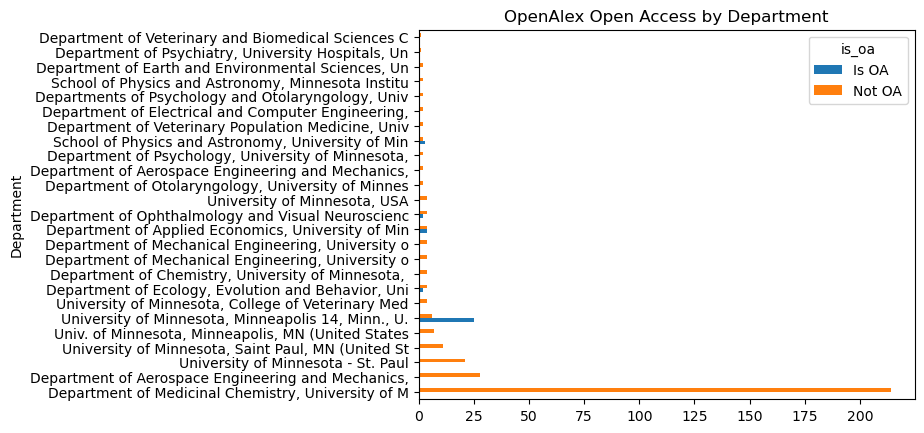

In [312]:
MN_departments_df.plot(x="Department", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Department')

In [322]:
MN_Year_df = counts('publication_year', 'is_oa', 'OA %', MN_df).sort_values(by='publication_year', ascending=False).reset_index(drop=True)
MN_Year_df = MN_Year_df[['publication_year', False, True]]
MN_Year_df = MN_Year_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year'})

MN_Year_df

is_oa,Publication Year,Not OA,Is OA
0,2024,16.0,5.0
1,2023,14.0,57.0
2,2022,229.0,148.0
3,2021,0.0,53.0
4,2020,10.0,144.0
5,2019,8.0,104.0
6,2018,5.0,105.0
7,2017,6.0,8.0
8,2016,10.0,29.0
9,2015,0.0,4.0


Text(0.5, 1.0, 'OpenAlex Open Access by Publication Year')

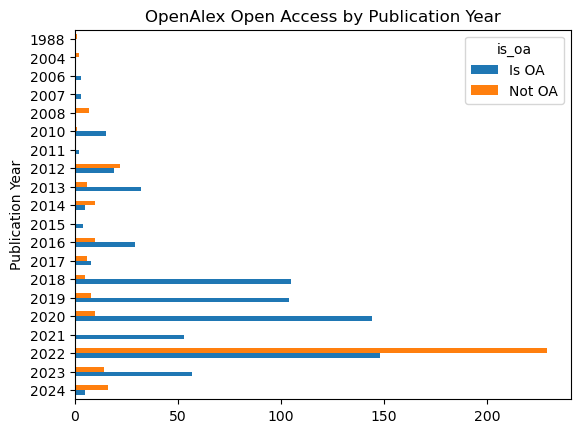

In [388]:
MN_Year_df.plot(x="Publication Year", y=['Is OA', 'Not OA'], kind="barh").set_title('OpenAlex Open Access by Publication Year')

In [358]:
MNAuthor_df = counts('author_name','is_oa', 'OA %', MN_df).sort_values(by=[False], ascending=False).reset_index(drop=True)
MNAuthor_df = MNAuthor_df[['author_name', False, True]]
MNAuthor_df = MNAuthor_df.rename(columns={False: 'Not OA', True: 'Is OA',  'author_name': 'Author'})
MNAuthor_df['Author Not OA%'] = MNAuthor_df['Not OA'] / MNAuthor_df['Not OA'].sum()
MNAuthor_df = MNAuthor_df.head(20)
MNAuthor_df

is_oa,Author,Not OA,Is OA,Author Not OA%
0,Phillip Portoghese,214.0,0.0,0.616715
1,Ellen K. Longmire,14.0,0.0,0.040346
2,Ankur Bordoloi,11.0,0.0,0.031700
3,E. B. Sandell,6.0,25.0,0.017291
4,Timothy J. Griffis,4.0,2.0,0.011527
5,Sharey Deep Guleria,4.0,0.0,0.011527
6,Matt Erickson,4.0,0.0,0.011527
7,Cody Winker,3.0,0.0,0.008646
8,Zachary W. Buell,3.0,0.0,0.008646
9,Alexandra R. Armstrong,2.0,0.0,0.005764


Text(0.5, 1.0, 'OpenAlex Open Access by Author')

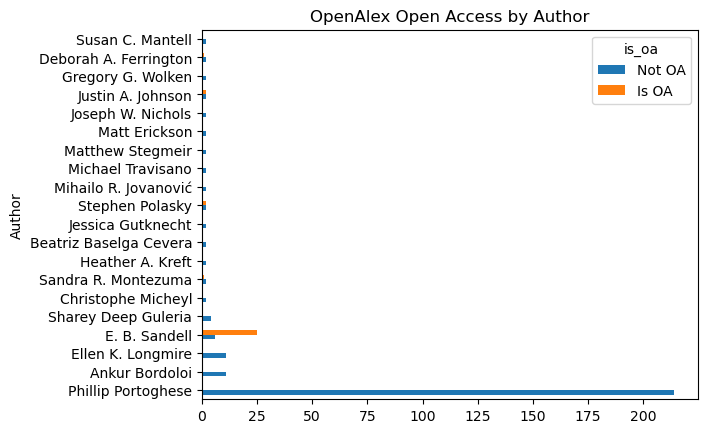

In [357]:
MNAuthor_plot = MNAuthor_df.plot(x="Author", y=['Not OA', 'Is OA'], kind="barh").set_title('OpenAlex Open Access by Author')

MNAuthor_plot

In [400]:
MN_Author_Context_df = MN_df.groupby(['author_name', 'publication_year', 'field_name'])['is_oa'].value_counts().unstack('is_oa').sort_values(by=[False], ascending=False).reset_index()
MN_Author_Context_df = MN_Author_Context_df.fillna(0)
#MN_Author_Context_df['OA %'] = MN_Author_Context_df[True] / (MN_Author_Context_df[False] + MN_Author_Context_df[True])
#MN_Author_Context_df['Total'] = MN_Author_Context_df[True] + MN_Author_Context_df[False]

MN_Author_Context_df = MN_Author_Context_df.rename(columns={False: 'Not OA', True: 'Is OA', 'publication_year': 'Publication Year', 'author_name': 'Author', 'field_name': 'Field Name'})
MN_Author_Context_df['% Of Not Open Access'] = MN_Author_Context_df['Not OA'] / MN_Author_Context_df['Not OA'].sum()
MN_Author_Context_df = MN_Author_Context_df.head(10)
MN_Author_Context_df

is_oa,Author,Publication Year,Field Name,Not OA,Is OA,% Of Not Open Access
0,Phillip Portoghese,2022,Computer Science,109.0,0.0,0.347134
1,Phillip Portoghese,2022,"Pharmacology, Toxicology and Pharmaceutics",34.0,0.0,0.108280
2,Phillip Portoghese,2022,"Biochemistry, Genetics and Molecular Biology",33.0,0.0,0.105096
3,Phillip Portoghese,2022,Medicine,20.0,0.0,0.063694
4,Phillip Portoghese,2022,Chemistry,11.0,0.0,0.035032
5,Phillip Portoghese,2022,Environmental Science,5.0,0.0,0.015924
6,Sharey Deep Guleria,2022,Engineering,4.0,0.0,0.012739
7,Ellen K. Longmire,2012,Engineering,4.0,0.0,0.012739
8,Ankur Bordoloi,2012,Engineering,4.0,0.0,0.012739
9,A. H. Sulaiman,2023,Physics and Astronomy,2.0,2.0,0.006369


In [377]:
remove_authors_df = MN_df[(MN_df.author_name != 'Phillip Portoghese') & (MN_df.author_name !='Ellen K. Longmire') & (MN_df.author_name !='Ankur Bordoloi')]

In [404]:
new_field_df = counts('field_name','is_oa', 'OA %', remove_authors_df).sort_values(by=[False], ascending=False).reset_index(drop=True).head(15)
new_field_df = new_field_df[['field_name', False, True]]
new_field_df = new_field_df.rename(columns={False: 'Not OA', True: 'Is OA',  'field_name': 'Field'})
new_field_df

is_oa,Field,Not OA,Is OA
0,Environmental Science,31.0,31.0
1,"Biochemistry, Genetics and Molecular Biology",12.0,22.0
2,Engineering,10.0,54.0
3,Agricultural and Biological Sciences,9.0,24.0
4,Physics and Astronomy,6.0,77.0
5,Computer Science,5.0,32.0
6,Earth and Planetary Sciences,4.0,37.0
7,Medicine,4.0,30.0
8,Veterinary,4.0,0.0
9,Social Sciences,2.0,117.0


Text(0.5, 1.0, 'OpenAlex Open Access by Author Without Outliers')

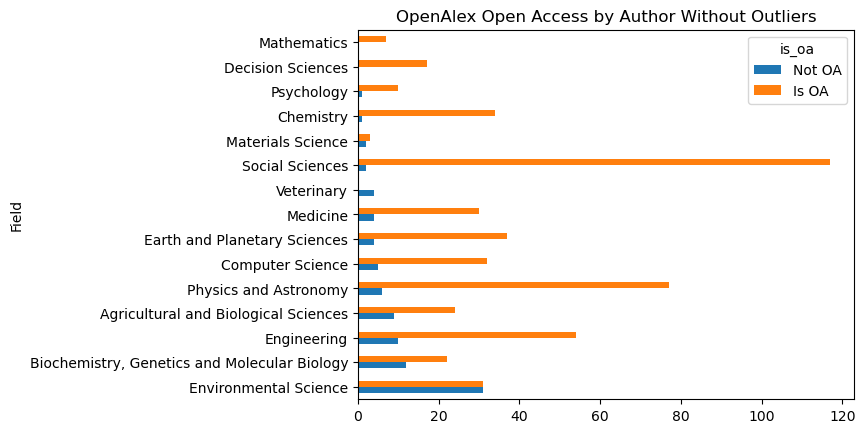

In [406]:
new_field_df.plot(x="Field", y=['Not OA', 'Is OA'], kind="barh").set_title('OpenAlex Open Access by Author Without Outliers')

In [283]:
mn_status_df = oa_status(MN_df, 'publication_year', 'oa_status', 'publication_year')
mn_status_df

oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2024,0.0,16.0,5.0,0.0,0.0,21.0,0.000000,0.000000,0.238095,0.761905,0.000000,closed
1,2023,0.0,14.0,57.0,0.0,0.0,71.0,0.000000,0.000000,0.802817,0.197183,0.000000,gold
2,2022,0.0,229.0,148.0,0.0,0.0,377.0,0.000000,0.000000,0.392573,0.607427,0.000000,closed
3,2021,0.0,0.0,53.0,0.0,0.0,53.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold
4,2020,0.0,10.0,142.0,0.0,2.0,154.0,0.012987,0.000000,0.922078,0.064935,0.000000,gold
5,2019,0.0,8.0,104.0,0.0,0.0,112.0,0.000000,0.000000,0.928571,0.071429,0.000000,gold
6,2018,1.0,5.0,103.0,1.0,0.0,110.0,0.000000,0.009091,0.936364,0.045455,0.009091,gold
7,2017,6.0,6.0,2.0,0.0,0.0,14.0,0.000000,0.000000,0.142857,0.428571,0.428571,closed
8,2016,26.0,10.0,0.0,0.0,3.0,39.0,0.076923,0.000000,0.000000,0.256410,0.666667,bronze
9,2015,0.0,0.0,4.0,0.0,0.0,4.0,0.000000,0.000000,1.000000,0.000000,0.000000,gold


<Axes: xlabel='publication_year'>

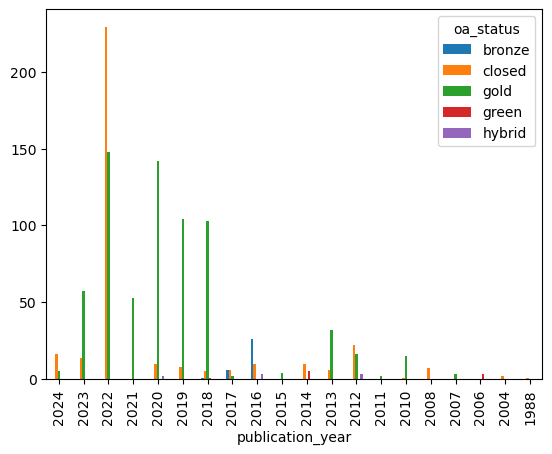

In [284]:
mn_status_plot = mn_status_df.plot(x="publication_year", y=["bronze", "closed", "gold", "green", "hybrid"], kind="bar")
mn_status_plot